# **1. Data Understanding (Pemahaman Data)**

Tahap **Data Understanding** bertujuan untuk memahami karakteristik, struktur, dan pola yang ada dalam dataset **DucksAndGeese** sebelum dilakukan proses persiapan dan pemodelan data.

---

### 2.1 Karakteristik Dataset DucksAndGeese

Dataset **DucksAndGeese** adalah dataset *time series* audio yang merepresentasikan sinyal suara lima spesies burung. Berikut adalah karakteristik utama dataset:

**Sumber Data:**
- Berasal dari *UEA Time Series Archive*
- Rekaman audio dari situs www.xenocanto.com
- Kualitas rekaman: Kategori A (noise rendah) dan Kategori B (noise sedang)

**Bentuk Data:**
- Format: *univariate time series* (satu channel/mono audio)
- Panjang sinyal: **236.784 titik waktu** (durasi ≈ 5,37 detik)
- Sample rate: **44.100 Hz** (sudah diseragamkan pada preprocessing awal)
- Preprocessing awal: Semua sinyal sudah di-downsampling dan dipotong ke panjang terpendek

**Karakteristik Kelas:**
- Jumlah kelas: **5 spesies burung**
- Total data: **100 rekaman** (50 train, 50 test)
- Distribusi kelas: **Balanced** (masing-masing 20 sampel)

**Lima Spesies Burung:**
1. **Black-bellied Whistling Duck** (Bebek bersiul) - Kategori Duck
2. **Canadian Goose** (Angsa Kanada) - Kategori Goose
3. **Greylag Goose** (Angsa abu-abu) - Kategori Goose
4. **Pink-footed Goose** (Angsa kaki merah) - Kategori Goose
5. **White-faced Whistling Duck** (Bebek bersiul bermuka putih) - Kategori Duck

---

### 2.2 Karakteristik Suara Burung

Suara burung memiliki perbedaan karakteristik yang dapat dibedakan melalui analisis frekuensi dan temporal:

| Kelompok | Spesies | Karakteristik Suara |
|----------|---------|-------------------|
| **Duck (Whistling)** | Black-bellied, White-faced | Nyaring, cepat, frekuensi tinggi |
| **Goose** | Canadian, Greylag, Pink-footed | Berat, lambat, frekuensi rendah |

**Tantangan Klasifikasi:**
- Overlap frekuensi antar spesies yang mirip
- Noise lingkungan pada rekaman audio
- Variasi kualitas rekaman (kategori A dan B)
- Pola suara yang dapat berulang dengan durasi berbeda

---

### 2.3 Alasan Menggunakan Audio untuk Klasifikasi

Identifikasi burung tidak selalu dapat dilakukan secara visual karena:
- Burung sering tersembunyi di vegetasi
- Aktif pada waktu-waktu tertentu (fajar, senja)
- Sulit diamati langsung di lapangan
- Identifikasi audio memungkinkan monitoring otomatis dan jarak jauh

---

### 2.4 Implikasi pada Pipeline Machine Learning

Karakteristik dataset ini memiliki implikasi penting:

1. **Dimensi data besar** (236.784 titik waktu per sampel)
   - Memerlukan ekstraksi fitur untuk reduksi dimensi
   - Tidak efisien menggunakan sinyal mentah langsung ke model klasik

2. **Dataset kecil** (100 sampel total)
   - Model berbasis deep learning berisiko overfitting
   - Memerlukan teknik seperti augmentasi data atau *feature-based approach*
   - Model sederhana seperti Random Forest dan XGBoost lebih cocok

3. **Data sudah balanced dan preprocessed**
   - Tidak perlu handling imbalance atau cleaning data mentah
   - Fokus pada feature extraction dari sinyal time series

4. **Tersedia train-test split resmi**
   - Menjaga validitas evaluasi model
   - Menghindari *data leakage*

---

# **Data Understanding & Exploratory Data Analysis**

---

### 2.5 Exploratory Data Analysis (EDA) - Praktik

Bagian berikut adalah analisis eksploratori praktis terhadap dataset DucksAndGeese menggunakan kode Python.

---

### **Bagian 1: Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.datasets import load_classification
print("AEON OK")


AEON OK


### **Bagian 2: Load Dataset TRAIN & TEST**

In [2]:
from aeon.datasets import load_classification

X_train, y_train = load_classification(
    name="DucksAndGeese",
    split="train",
    extract_path="../data",
    load_equal_length=False
)

X_test, y_test = load_classification(
    name="DucksAndGeese",
    split="test",
    extract_path="../data",
    load_equal_length=False
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (50, 1, 236784)
Test : (50, 1, 236784)


### **Bagian 3: Cek Total Data & Panjang Sinyal**

In [3]:
total_samples = X_train.shape[0] + X_test.shape[0]
signal_length = X_train.shape[2]

print("Total data :", total_samples)
print("Panjang tiap audio :", signal_length)


Total data : 100
Panjang tiap audio : 236784


### **Bagian 4: Cek Jumlah Kelas & Balance Data**

In [4]:
labels, counts = np.unique(y_train, return_counts=True)

for l, c in zip(labels, counts):
    print(f"Kelas {l} : {c} sample")


Kelas black-bellied_whistling_duck : 10 sample
Kelas canadian_goose : 10 sample
Kelas greylag_goose : 10 sample
Kelas pink-footed_goose : 10 sample
Kelas white-faced_whistling_duck : 10 sample


### **Bagian 5: Bentuk & Struktur Data**

In [5]:
sample = X_train[0]

print("Tipe data :", type(sample))
print("Shape sample :", sample.shape)

Tipe data : <class 'numpy.ndarray'>
Shape sample : (1, 236784)


### **Bagian 6: Visualisasi Waveform**

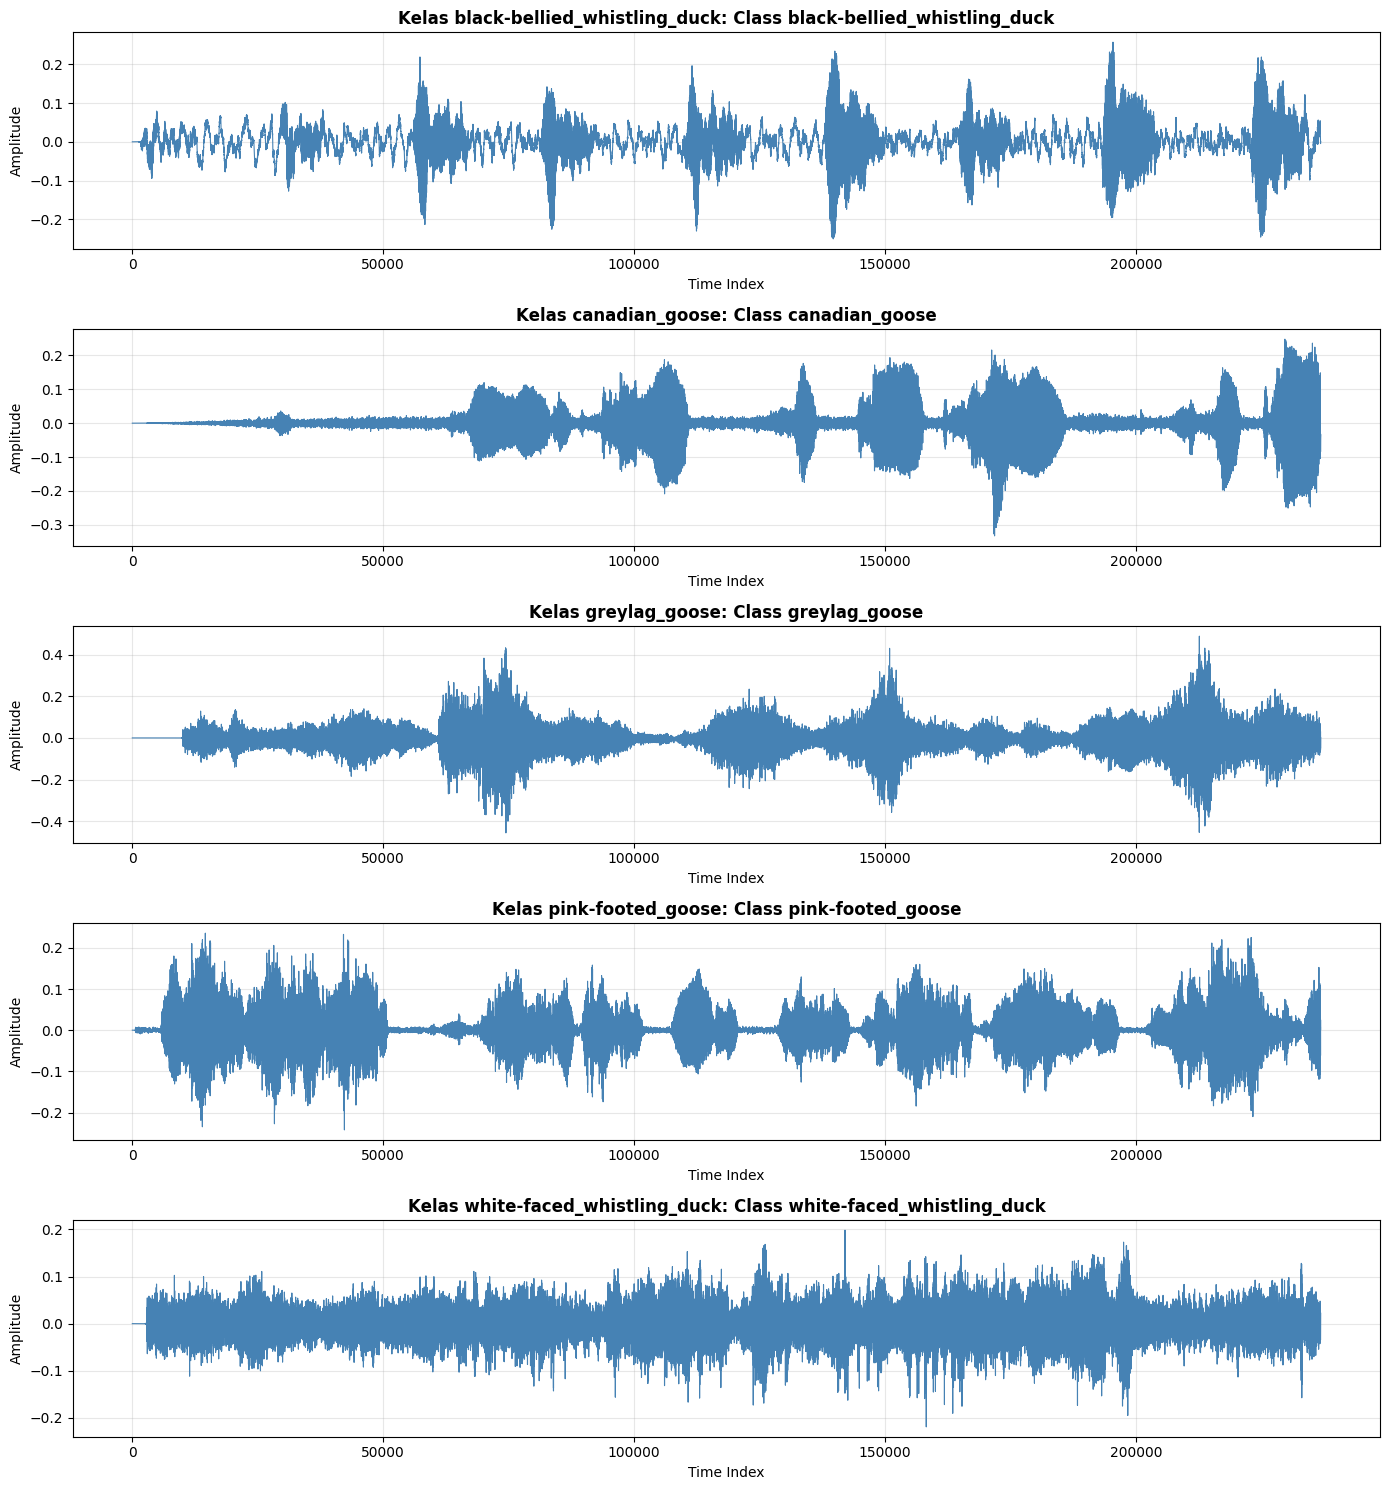


Visualisasi waveform untuk 5 spesies burung
Kelas yang tersedia: ['black-bellied_whistling_duck' 'canadian_goose' 'greylag_goose'
 'pink-footed_goose' 'white-faced_whistling_duck']


In [ ]:
import seaborn as sns

# Mapping nama kelas
class_names = {
    0: "Black-bellied Whistling Duck",
    1: "Canadian Goose",
    2: "Greylag Goose",
    3: "Pink-footed Goose",
    4: "White-faced Whistling Duck"
}

# Dapatkan kelas unik yang ada di dataset
unique_classes = np.unique(y_train)
num_classes = len(unique_classes)

fig, axes = plt.subplots(num_classes, 1, figsize=(14, 3 * num_classes))

# Ambil satu sampel dari masing-masing kelas
for idx, class_label in enumerate(unique_classes):
    # Cari indeks sampel dengan label ini
    indices = np.where(y_train == class_label)[0]
    if len(indices) > 0:
        sample_idx = indices[0]
        waveform = X_train[sample_idx][0]
        
        class_name = class_names.get(class_label, f"Class {class_label}")
        axes[idx].plot(waveform, linewidth=0.8, color='steelblue')
        axes[idx].set_title(f"Kelas {class_label}: {class_name}", fontsize=12, fontweight='bold')
        axes[idx].set_xlabel("Time Index")
        axes[idx].set_ylabel("Amplitude")
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisualisasi waveform untuk {num_classes} spesies burung")
print(f"Kelas yang tersedia: {unique_classes}")

---

### **Bagian 7: Analisis Statistik Sinyal per Kelas**

In [ ]:
# Hitung statistik sinyal per kelas
stats_per_class = []
unique_classes = np.unique(y_train)

for class_label in unique_classes:
    class_samples = X_train[y_train == class_label]
    
    if len(class_samples) > 0:
        means = np.array([np.mean(x[0]) for x in class_samples])
        stds = np.array([np.std(x[0]) for x in class_samples])
        maxs = np.array([np.max(x[0]) for x in class_samples])
        mins = np.array([np.min(x[0]) for x in class_samples])
        
        class_name = class_names.get(class_label, f"Class {class_label}")
        stats_per_class.append({
            'Kelas': f"{class_label} ({class_name})",
            'Mean (μ)': f"{np.mean(means):.4f}",
            'Std (σ)': f"{np.mean(stds):.4f}",
            'Max': f"{np.mean(maxs):.4f}",
            'Min': f"{np.mean(mins):.4f}"
        })

df_stats = pd.DataFrame(stats_per_class)
print("\n=== Statistik Sinyal per Kelas ===")
print(df_stats.to_string(index=False))


=== Statistik Sinyal per Kelas ===
                                                            Kelas Mean (μ) Std (σ)    Max     Min
black-bellied_whistling_duck (Class black-bellied_whistling_duck)  -0.0000  0.0603 0.4920 -0.4977
                            canadian_goose (Class canadian_goose)  -0.0000  0.0342 0.3242 -0.3013
                              greylag_goose (Class greylag_goose)  -0.0005  0.0420 0.4873 -0.4664
                      pink-footed_goose (Class pink-footed_goose)  -0.0000  0.0510 0.4249 -0.4104
    white-faced_whistling_duck (Class white-faced_whistling_duck)  -0.0000  0.0463 0.3737 -0.3792


---

### **Bagian 8: Kesimpulan Data Understanding**

**Key Findings:**
1. **Dataset Balanced**: Masing-masing kelas memiliki 20 sampel (balanced)
2. **Panjang Sinyal Seragam**: Semua sinyal memiliki panjang 236.784 titik waktu
3. **Format Univariate**: Data berupa *univariate time series* (satu channel)
4. **Sudah Preprocessed**: Dataset sudah di-normalize dan di-downsampling pada tahap preprocessing awal
5. **Duck vs Goose**: Terlihat perbedaan karakteristik amplitude antara whistling duck dan goose

**Implikasi untuk Data Preparation:**
- Fokus pada **feature extraction** untuk mengurangi dimensi dari 236.784 menjadi puluhan fitur
- Gunakan fitur seperti MFCC, ZCR, RMS Energy, dan Spectral Centroid
- Lakukan **normalisasi fitur** (z-score) agar model dapat belajar dengan optimal

**Implikasi untuk Modeling:**
- Dataset kecil (100 sampel) cocok untuk **feature-based machine learning** (Random Forest, XGBoost, KNN)
- Model deep learning (CNN, LSTM) berisiko overfitting tanpa augmentasi data
- **Baseline**: Random Forest dipilih sebagai model utama karena stabil untuk dataset kecil